In [1]:
from glob import glob
import h5py
import numpy as np
from tqdm import tqdm
import colorcet as cc
import matplotlib.pyplot as plt
import scistyles

In [2]:
%matplotlib widget
plt.style.use("report-sp")

In [3]:
def load_mat(fname): #dude
    arrays = {}
    with h5py.File(fname, 'r') as f:
        for k in f.keys():
            if k == "#refs#":
                continue
            if f[k].dtype.name == "object":
                shape = np.shape(f[k])
                arr = np.array([f[v] for v in np.ravel(f[k][...,0])]).reshape(shape) # don't ask
                arrays[k] = arr
            else:
                arrays[k] = f[k][:]
    return arrays

In [4]:
def best_vertex(c, v):
    idx = np.argmin(v[-1,:])
    return c[-1, idx, :], v[-1, idx]

In [5]:
fnames = glob("e1_*simplex.mat")
fnames = sorted(fnames, key=lambda n:int(n.split("_")[1]))

In [6]:
payload = {fn: load_mat(fn) for fn in tqdm(fnames)}
data = [(v["points"], v["values"]) for v in payload.values()]

100%|████████████████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 1681.19it/s]


In [7]:
nit = [int(fn.split("_")[1]) for fn in fnames]

In [8]:
best_c = []
best_v = []
for e in data:
    b = best_vertex(*e)
    best_c.append(b[0])
    best_v.append(b[1])
best_c = np.array(best_c)
best_c_rel = best_c / best_c[-1]
best_v = np.array(best_v)

In [9]:
# compute size of last simplex
last_vertices = np.array([c[-1,:,:] for c, _ in data])
first_vertices = np.array([c[0,:,:] for c, _ in data])
mid_vertices = np.array([c[c.shape[0]//2,:,:] for c, _ in data])
p_vertices = np.array([c[c.shape[0]//8,:,:] for c, _ in data])

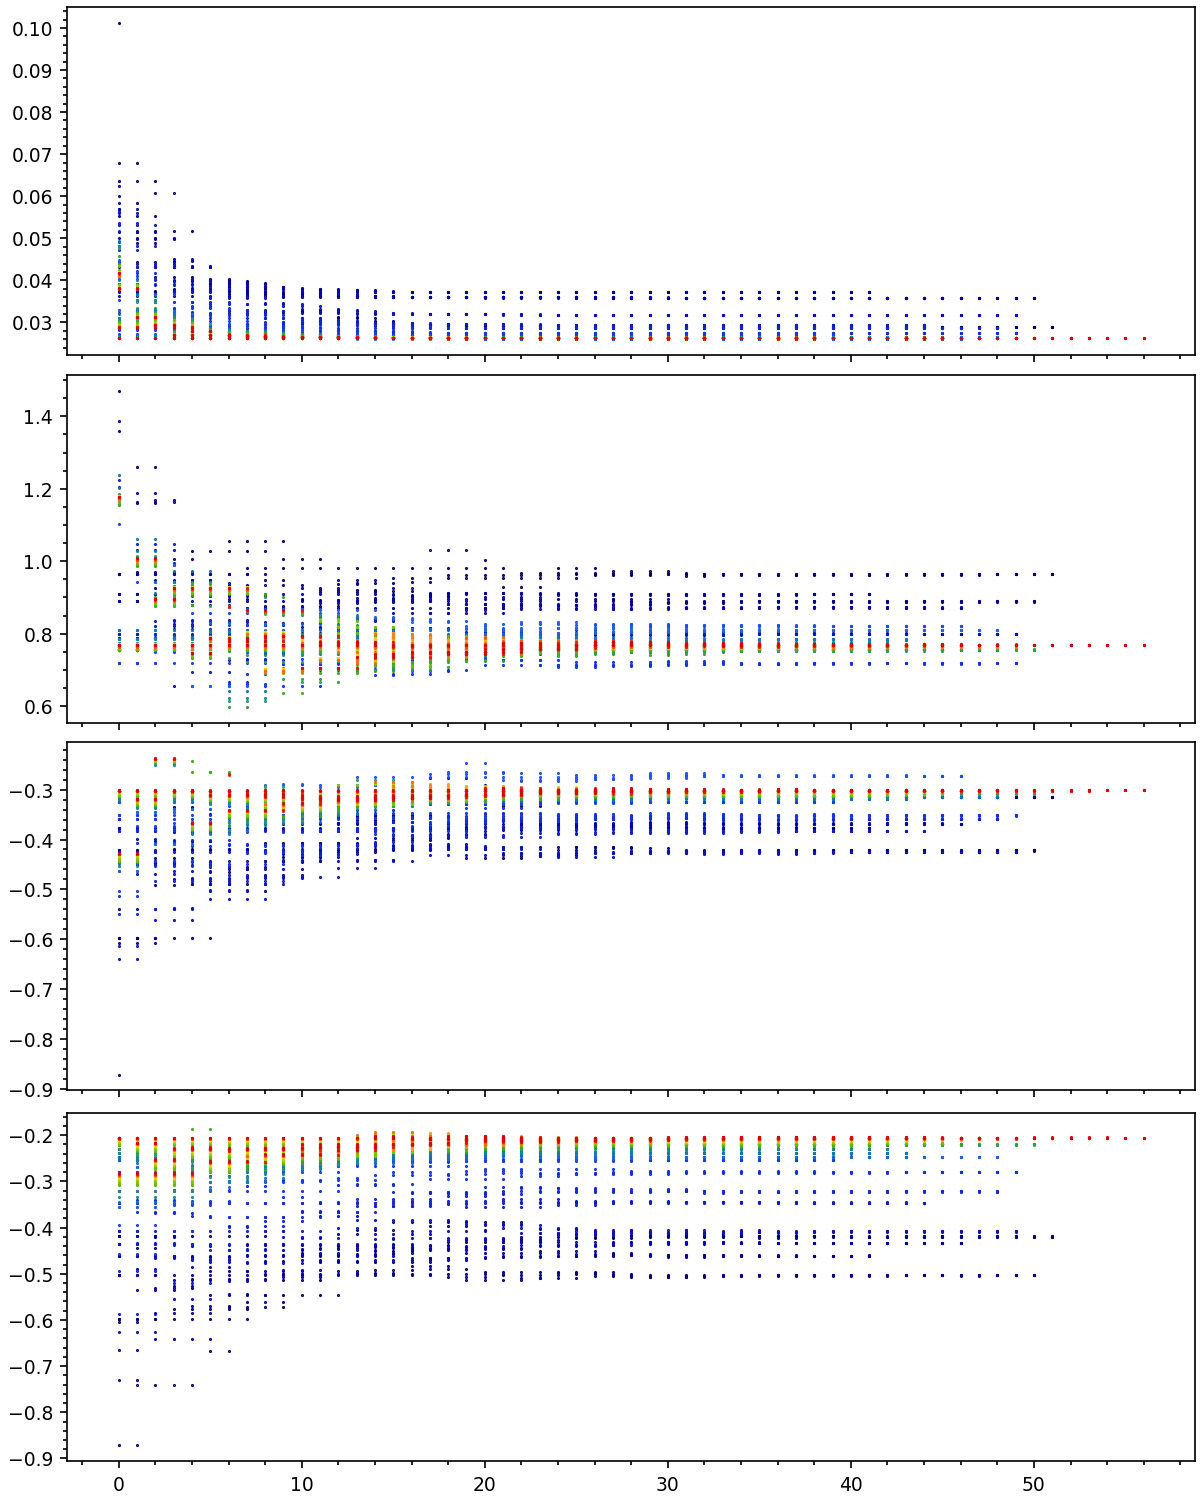

In [10]:
N_traj = len(data)
N_dims = 3
N_vertex = N_dims+1

fig, axes = plt.subplots(nrows=N_dims+1, figsize=(8, 10), sharex=True)

traj_palette = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, N_traj))
for traj_idx, (coords_trace, values_trace) in enumerate(data):
    traj_len = values_trace.shape[0]
    pt_idx = np.arange(traj_len)
    assert values_trace.ndim == 2
    plt.sca(axes[0])
    plt.plot(pt_idx, values_trace,  '.', c=traj_palette[traj_idx], ms=1)
    for i in range(N_dims):
        plt.sca(axes[i+1])
        plt.plot(pt_idx, coords_trace[:,:,i], ".", c=traj_palette[traj_idx], ms=1)


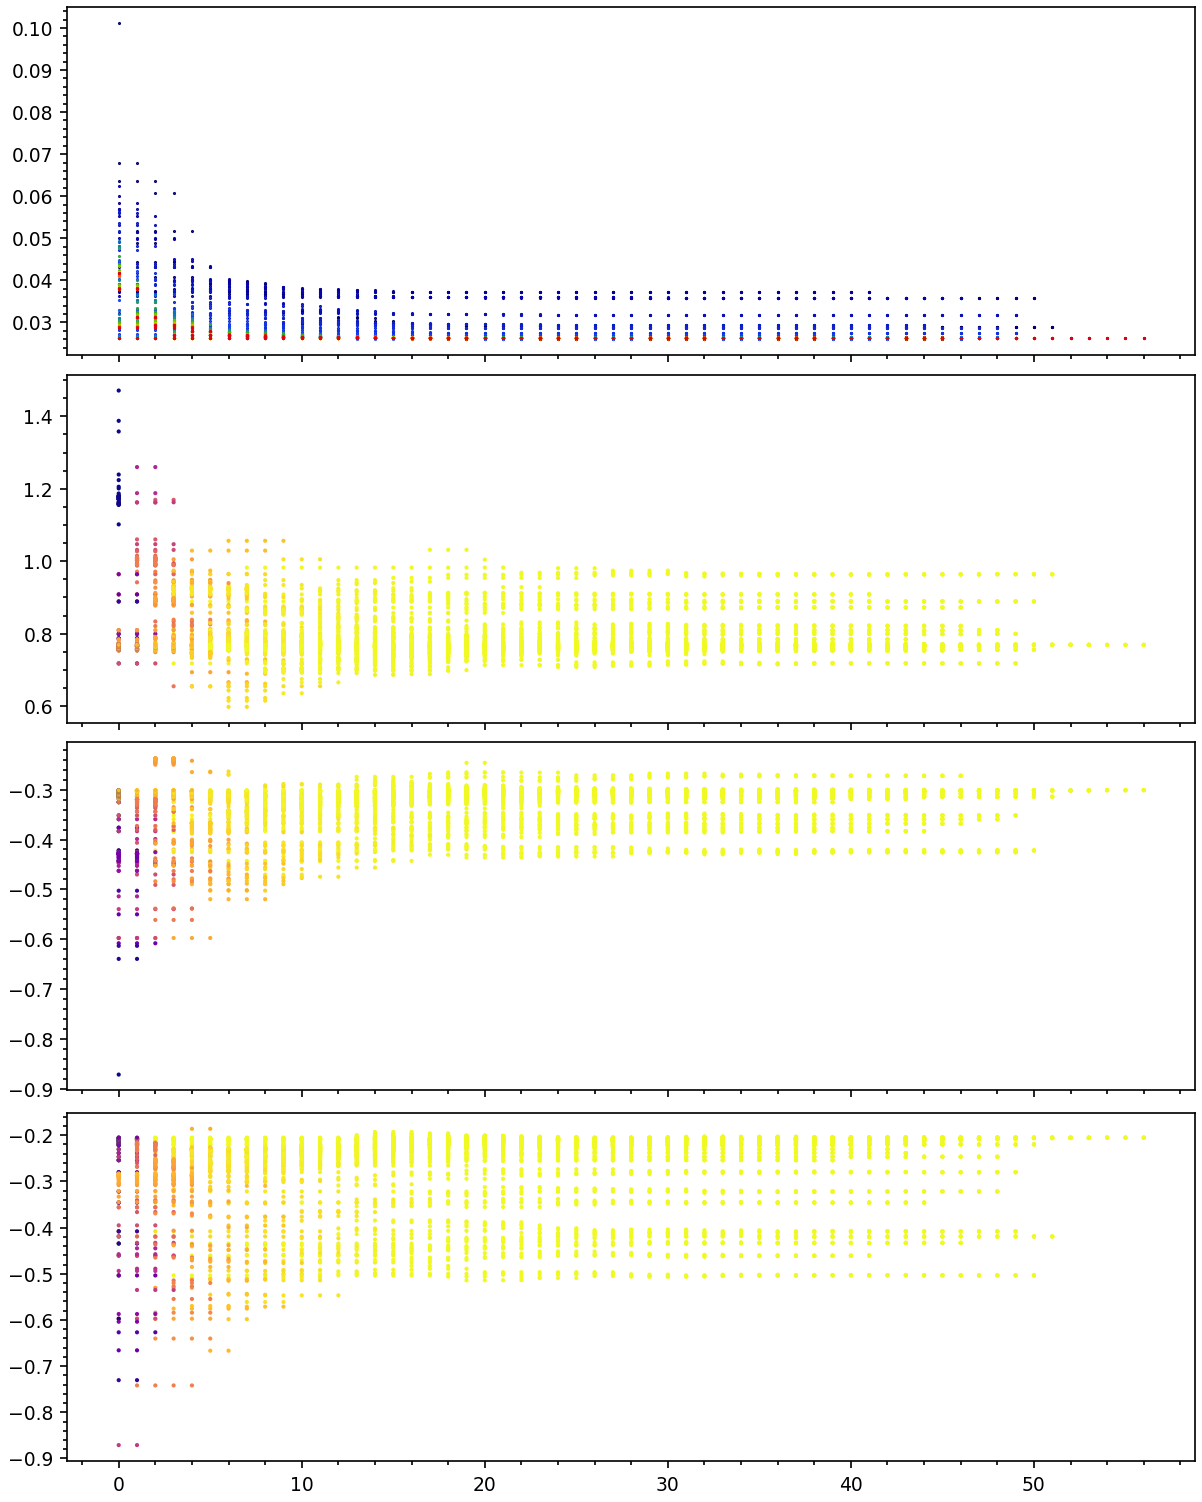

In [11]:
N_traj = len(data)
N_dims = 3
N_vertex = N_dims+1

fig, axes = plt.subplots(nrows=N_dims+1, figsize=(8, 10), sharex=True)

traj_palette = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, N_traj))


for traj_idx, (coords_trace, values_trace) in enumerate(data):
    traj_len = values_trace.shape[0]
    pt_idx = np.arange(traj_len)
    assert values_trace.ndim == 2
    plt.sca(axes[0])
    plt.plot(pt_idx, values_trace,  '.', c=traj_palette[traj_idx], ms=1)
    v_palette = plt.get_cmap("cet_fire")
    norm = plt.Normalize(np.min(values_trace), np.max(values_trace))
    colors = v_palette(norm(values_trace))
    for i in range(N_dims):
        plt.sca(axes[i+1])
        plt.scatter(np.tile(pt_idx, (4,1)).T, coords_trace[:,:,i], c=values_trace, norm=norm, cmap="plasma_r", s=1)


In [12]:
grad_c = np.diff(best_c, axis=0)

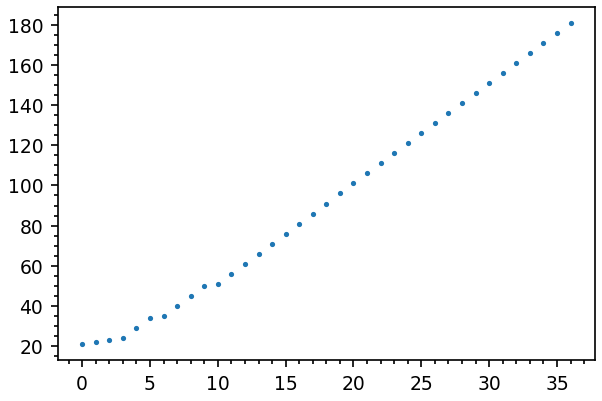

In [13]:
plt.figure()
plt.plot(nit, ".")

Text(0, 0.5, 'Internal coordinates')

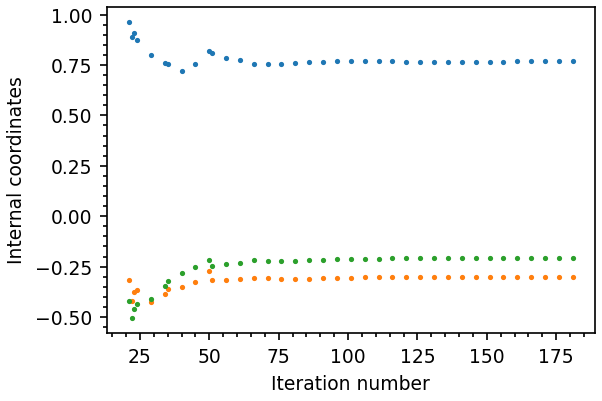

In [14]:
plt.figure()
plt.plot(nit, best_c, ".")
plt.xlabel("Iteration number")
plt.ylabel("Internal coordinates")

In [15]:
spans = last_vertices - best_c[:,np.newaxis,:]

In [16]:
spans.shape

(37, 4, 3)

Text(0.5, 0, 'Iteration number')

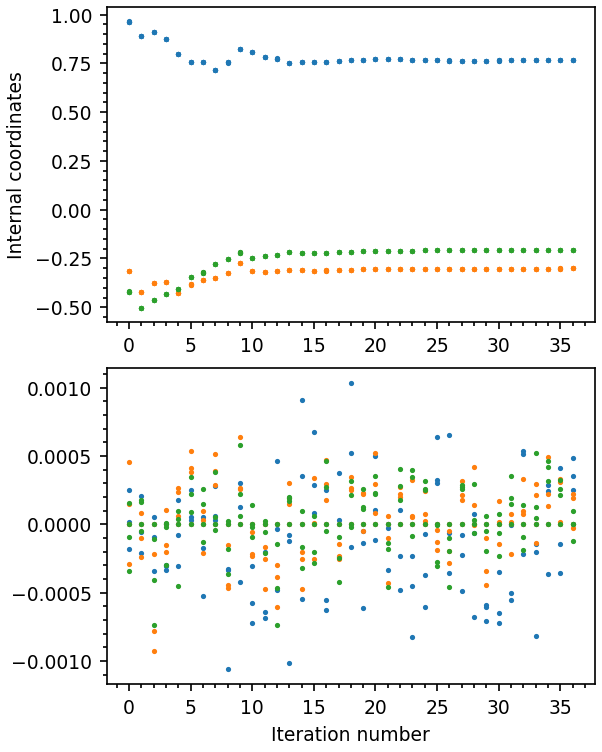

In [17]:
fig, axes = plt.subplots(nrows=2, figsize=(4,5))
plt.sca(axes[0])
colors = []
iter_idx = np.arange(best_c.shape[0])
_ = plt.plot(iter_idx, best_c, ".")
colors = ["C0", "C1", "C2"]
plt.ylabel("Internal coordinates")
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    _ = plt.plot(iter_idx, last_vertices[:,:,coord], ".", c=c)
plt.sca(axes[1])
spans = last_vertices - best_c[:,np.newaxis,:]
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    plt.plot(iter_idx, spans[:,:,coord], ".", c=c)
plt.xlabel("Iteration number")

Text(0.5, 0, 'Iteration number')

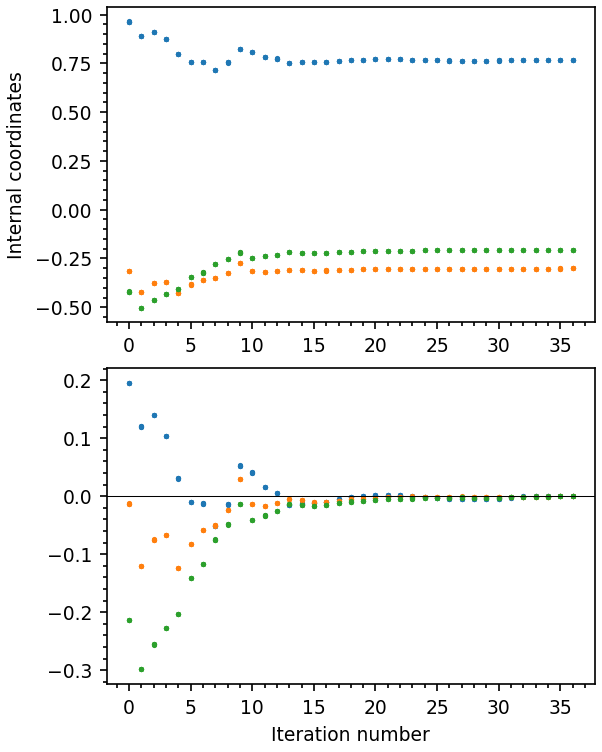

In [18]:
fig, axes = plt.subplots(nrows=2, figsize=(4,5))
plt.sca(axes[0])
colors = []
iter_idx = np.arange(best_c.shape[0])
_ = plt.plot(iter_idx, best_c, ".")
colors = ["C0", "C1", "C2"]
plt.ylabel("Internal coordinates")
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    _ = plt.plot(iter_idx, last_vertices[:,:,coord], ".", c=c)
plt.sca(axes[1])
spans = last_vertices - best_c[-1,:]
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    plt.plot(iter_idx, spans[:,:,coord], ".", c=c)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Iteration number")

Text(0.5, 0, 'Iteration number')

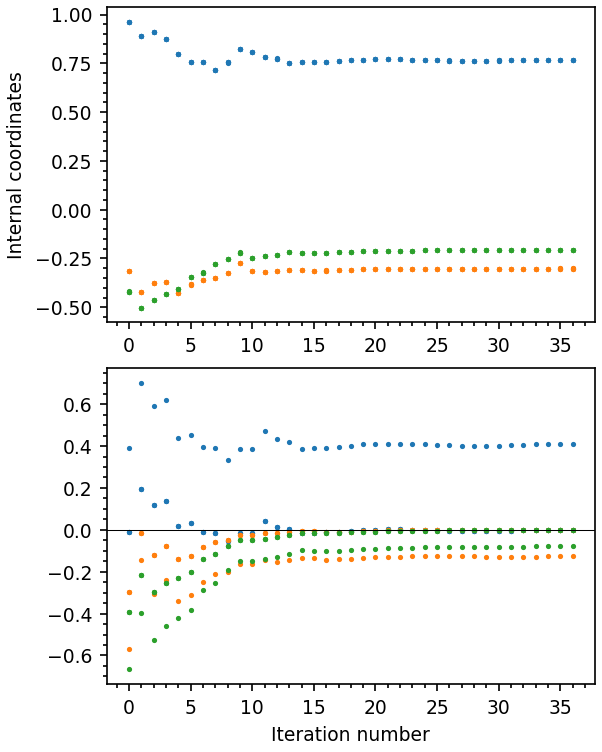

In [19]:
fig, axes = plt.subplots(nrows=2, figsize=(4,5))
plt.sca(axes[0])
colors = []
iter_idx = np.arange(best_c.shape[0])
_ = plt.plot(iter_idx, best_c, ".")
colors = ["C0", "C1", "C2"]
plt.ylabel("Internal coordinates")
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    _ = plt.plot(iter_idx, last_vertices[:,:,coord], ".", c=c)
plt.sca(axes[1])
spans = first_vertices - best_c[-1,:]
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    plt.plot(iter_idx, spans[:,:,coord], ".", c=c)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Iteration number")

Text(0.5, 0, 'Iteration number')

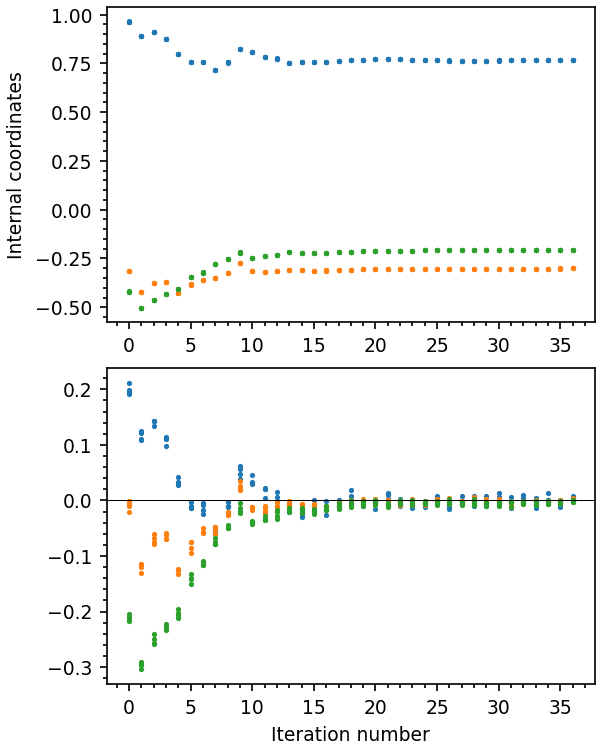

In [20]:
fig, axes = plt.subplots(nrows=2, figsize=(4,5))
plt.sca(axes[0])
colors = []
iter_idx = np.arange(best_c.shape[0])
_ = plt.plot(iter_idx, best_c, ".")
colors = ["C0", "C1", "C2"]
plt.ylabel("Internal coordinates")
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    _ = plt.plot(iter_idx, last_vertices[:,:,coord], ".", c=c)
plt.sca(axes[1])
spans = mid_vertices - best_c[-1,:]
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    plt.plot(iter_idx, spans[:,:,coord], ".", c=c)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Iteration number")

Text(0.5, 0, 'Iteration number')

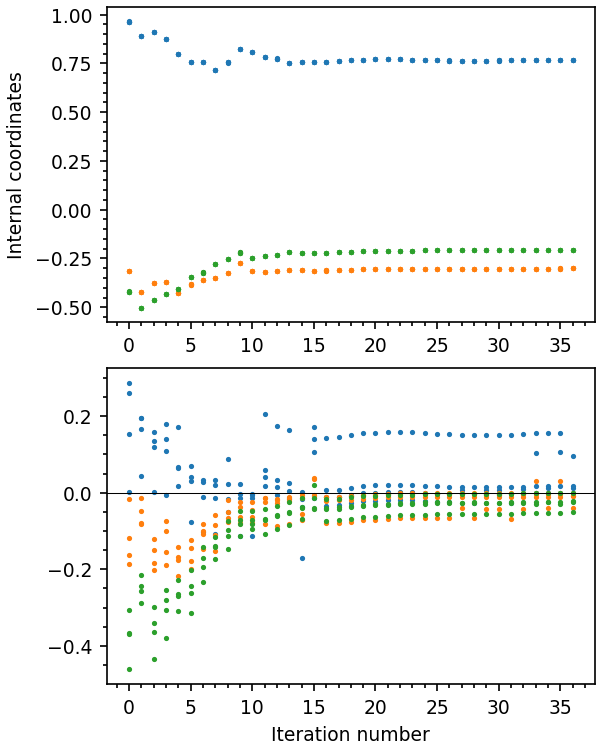

In [21]:
fig, axes = plt.subplots(nrows=2, figsize=(4,5))
plt.sca(axes[0])
colors = []
iter_idx = np.arange(best_c.shape[0])
_ = plt.plot(iter_idx, best_c, ".")
colors = ["C0", "C1", "C2"]
plt.ylabel("Internal coordinates")
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    _ = plt.plot(iter_idx, last_vertices[:,:,coord], ".", c=c)
plt.sca(axes[1])
spans = p_vertices - best_c[-1,:]
for coord, c in zip(np.arange(last_vertices.shape[-1]), colors):
    plt.plot(iter_idx, spans[:,:,coord], ".", c=c)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Iteration number")

Text(0, 0.5, 'Gradient, Internal coordinates')

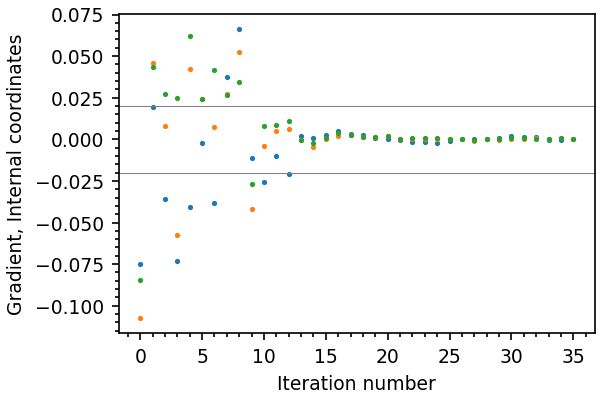

In [22]:
plt.figure()
plt.plot(np.arange(grad_c.shape[0]), grad_c, ".")
thresh = [0.02, -0.02]
for v in thresh:
    plt.axhline(v, lw=0.5, c="0.5")
plt.xlabel("Iteration number")
plt.ylabel("Gradient, Internal coordinates")

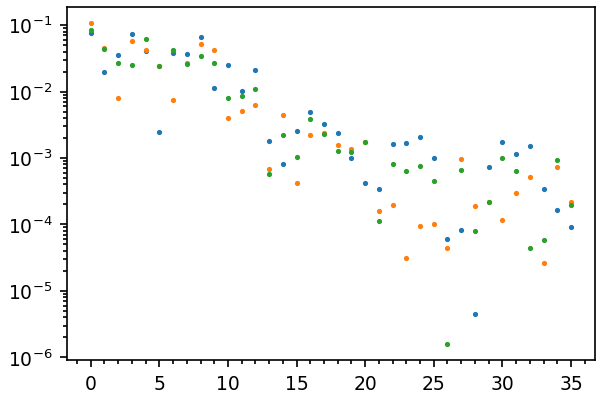

In [23]:
plt.figure()
plt.plot(np.arange(grad_c.shape[0]), np.abs(grad_c), ".")
plt.yscale("log")

C:\Users\palatosa\AppData\Local\Temp\ipykernel_11952\2661333164.py:3: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(iter_idx[1:], np.sqrt(np.sum(grad_c, axis=1)), ".", label="gradient")


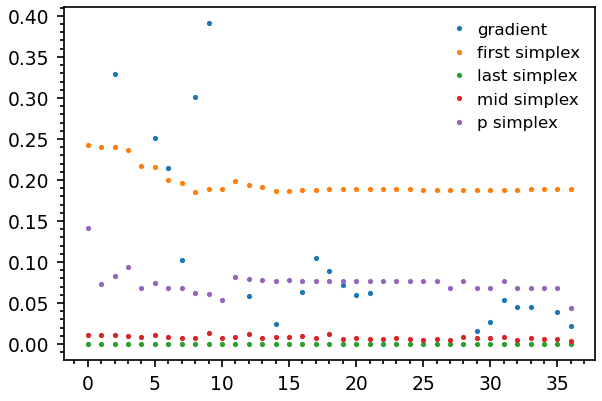

In [24]:
plt.figure()

plt.plot(iter_idx[1:], np.sqrt(np.sum(grad_c, axis=1)), ".", label="gradient")
plt.plot(iter_idx, np.sqrt(np.sum(np.var(first_vertices, axis=1), axis=-1)), ".", label="first simplex")
plt.plot(iter_idx, np.sqrt(np.sum(np.var(last_vertices, axis=1), axis=-1)), ".", label="last simplex")
plt.plot(iter_idx, np.sqrt(np.sum(np.var(mid_vertices, axis=1), axis=-1)), ".", label="mid simplex")
plt.plot(iter_idx, np.sqrt(np.sum(np.var(p_vertices, axis=1), axis=-1)), ".", label="p simplex")
plt.legend()


In [25]:
# The pareto simplex seems to have the best extent.